In [28]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch.optim
import torch.nn as nn
import seaborn as sns
from PIL import Image
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [29]:
images = pd.read_csv('./V1/d1.csv')
y = images['label']
X = images.drop('label', axis=1)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,    
    random_state=42    
)


images_test = pd.read_csv('./V1/mnist_test.csv')
y_test = images_test['label']
X_test = images_test.drop('label', axis=1)

In [3]:
manifold = umap.UMAP(random_state=42).fit(X, y)
X_reduced = manifold.transform(X)
print(X.shape, X_reduced.shape)

/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(60000, 784) (60000, 2)


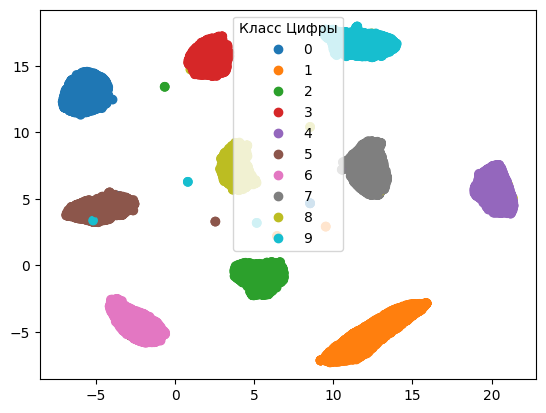

In [4]:
%matplotlib inline
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

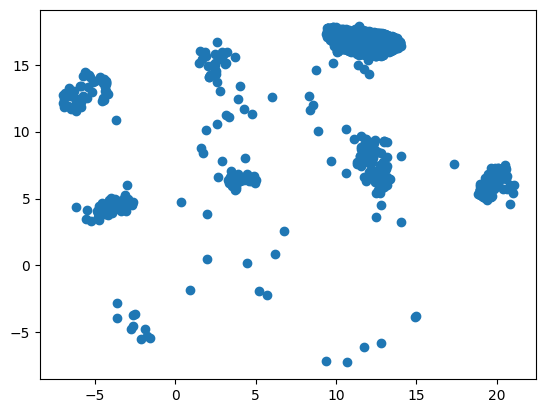

In [5]:
nines = images[images['label'] == 9]
nine_reduced = manifold.transform(nines)
plt.scatter(nine_reduced[:, 0], nine_reduced[:, 1])

In [6]:
lof = LocalOutlierFactor(n_neighbors=15, contamination=0.001)
is_inliner = lof.fit_predict(X_reduced)
X_copy = X.copy()
X_copy['is_anomaly'] = is_inliner
anomalies = X_copy[X_copy['is_anomaly'] == -1]
print(len(anomalies))

60


In [59]:
first_row = X.iloc[1]
def to_image(str_img):
    return Image.fromarray(np.array(str_img,dtype=np.uint8).reshape((28,28)), mode='L')
image1 = to_image(first_row)

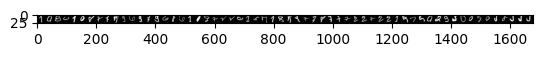

In [8]:
show_anomalies = []
for i in range(len(anomalies)):
    show_anomalies.append(to_image(anomalies.iloc[i].drop('is_anomaly')))

total_width = sum(img.width for img in show_anomalies)
max_height = max(img.height for img in show_anomalies)

horizontal_combo = Image.new("RGB", (total_width, max_height))

x_offset = 0
for img in show_anomalies:
    horizontal_combo.paste(img, (x_offset, 0))
    x_offset += img.width

plt.imshow(horizontal_combo)

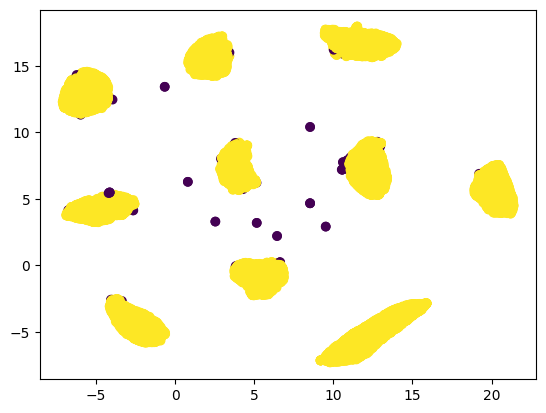

In [11]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=X_copy['is_anomaly'])

(60000, 2)


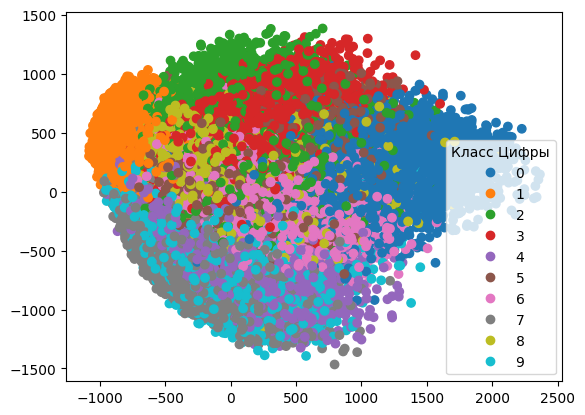

In [12]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X)
print(X_train_pca.shape)
scatter_pca = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter_pca.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

In [13]:
from sklearn.manifold import TSNE
model = TSNE(n_components = 2, random_state = 42)

tsne_data = model.fit_transform(X)


(60000, 2)


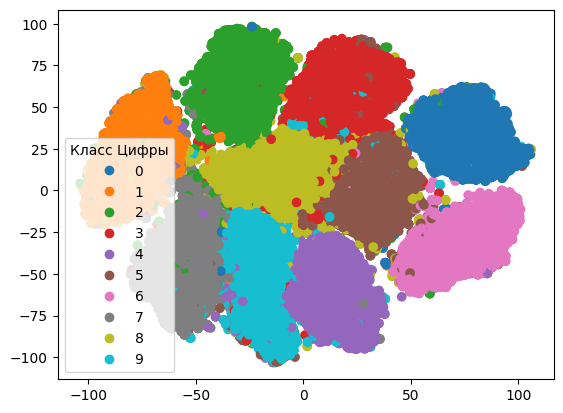

In [14]:
print(tsne_data.shape)
scatter_tsne = plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter_tsne.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

(array([5923., 6742., 5958., 6131., 5842., 5421., 5918., 6265., 5851.,
        5949.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

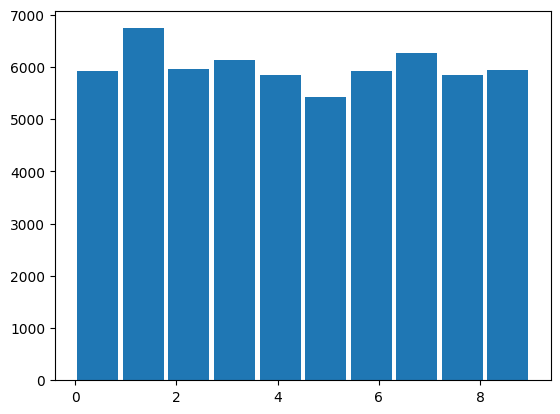

In [15]:
# images['label'].hist()
plt.hist(images['label'], rwidth=0.9)

<Axes: >

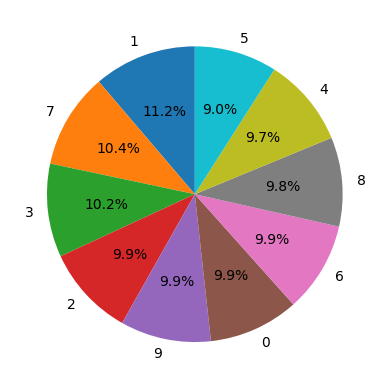

In [16]:
images['label'].value_counts().plot.pie(autopct='%1.1f%%', 
    startangle=90, 
    ylabel='')

In [17]:
counts = images['label'].value_counts()
imbalance_ratio = counts.max() / counts.min()
print('Коэффициент дисбаланса', imbalance_ratio)
print('Индекс Gini:', 1 - (images['label'].value_counts(normalize=True) ** 2).sum())

Коэффициент дисбаланса 1.243681977494927
Индекс Gini: 0.8997118405555555


In [40]:
print(images[images['label'] == 4]['label'].count())
print(images['label'].value_counts())
# images['label'].unique()


5842
label
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64


In [ ]:
print(y_train.value_counts().loc[5], y_train.unique())

4317 [5 0 1 6 3 8 4 7 2 9]


In [57]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

need_to_over_smaple = {}
mdeian_count = y_train.value_counts().median()
val = y_train.unique().tolist()
for i in val:
    need_to_over_smaple[i] = np.int64(max(mdeian_count, y_train.value_counts().loc[i]))
print(need_to_over_smaple)

ros = RandomOverSampler(sampling_strategy=need_to_over_smaple, random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
print("После Oversampling:", Counter(y_resampled))

need_to_under_smaple = {}
for i in val:
    need_to_under_smaple[i] = mdeian_count

rus = RandomUnderSampler(random_state=42)
X_resampled_un, y_resampled_un = rus.fit_resample(X_resampled, y_resampled)
print("После Undersampling:", Counter(y_resampled_un))

{5: np.int64(4751), 0: np.int64(4751), 1: np.int64(5420), 6: np.int64(4751), 3: np.int64(4912), 8: np.int64(4751), 4: np.int64(4751), 7: np.int64(4966), 2: np.int64(4784), 9: np.int64(4755)}
После Oversampling: Counter({1: 5420, 7: 4966, 3: 4912, 2: 4784, 9: 4755, 5: 4751, 0: 4751, 6: 4751, 8: 4751, 4: 4751})
После Undersampling: Counter({0: 4751, 1: 4751, 2: 4751, 3: 4751, 4: 4751, 5: 4751, 6: 4751, 7: 4751, 8: 4751, 9: 4751})


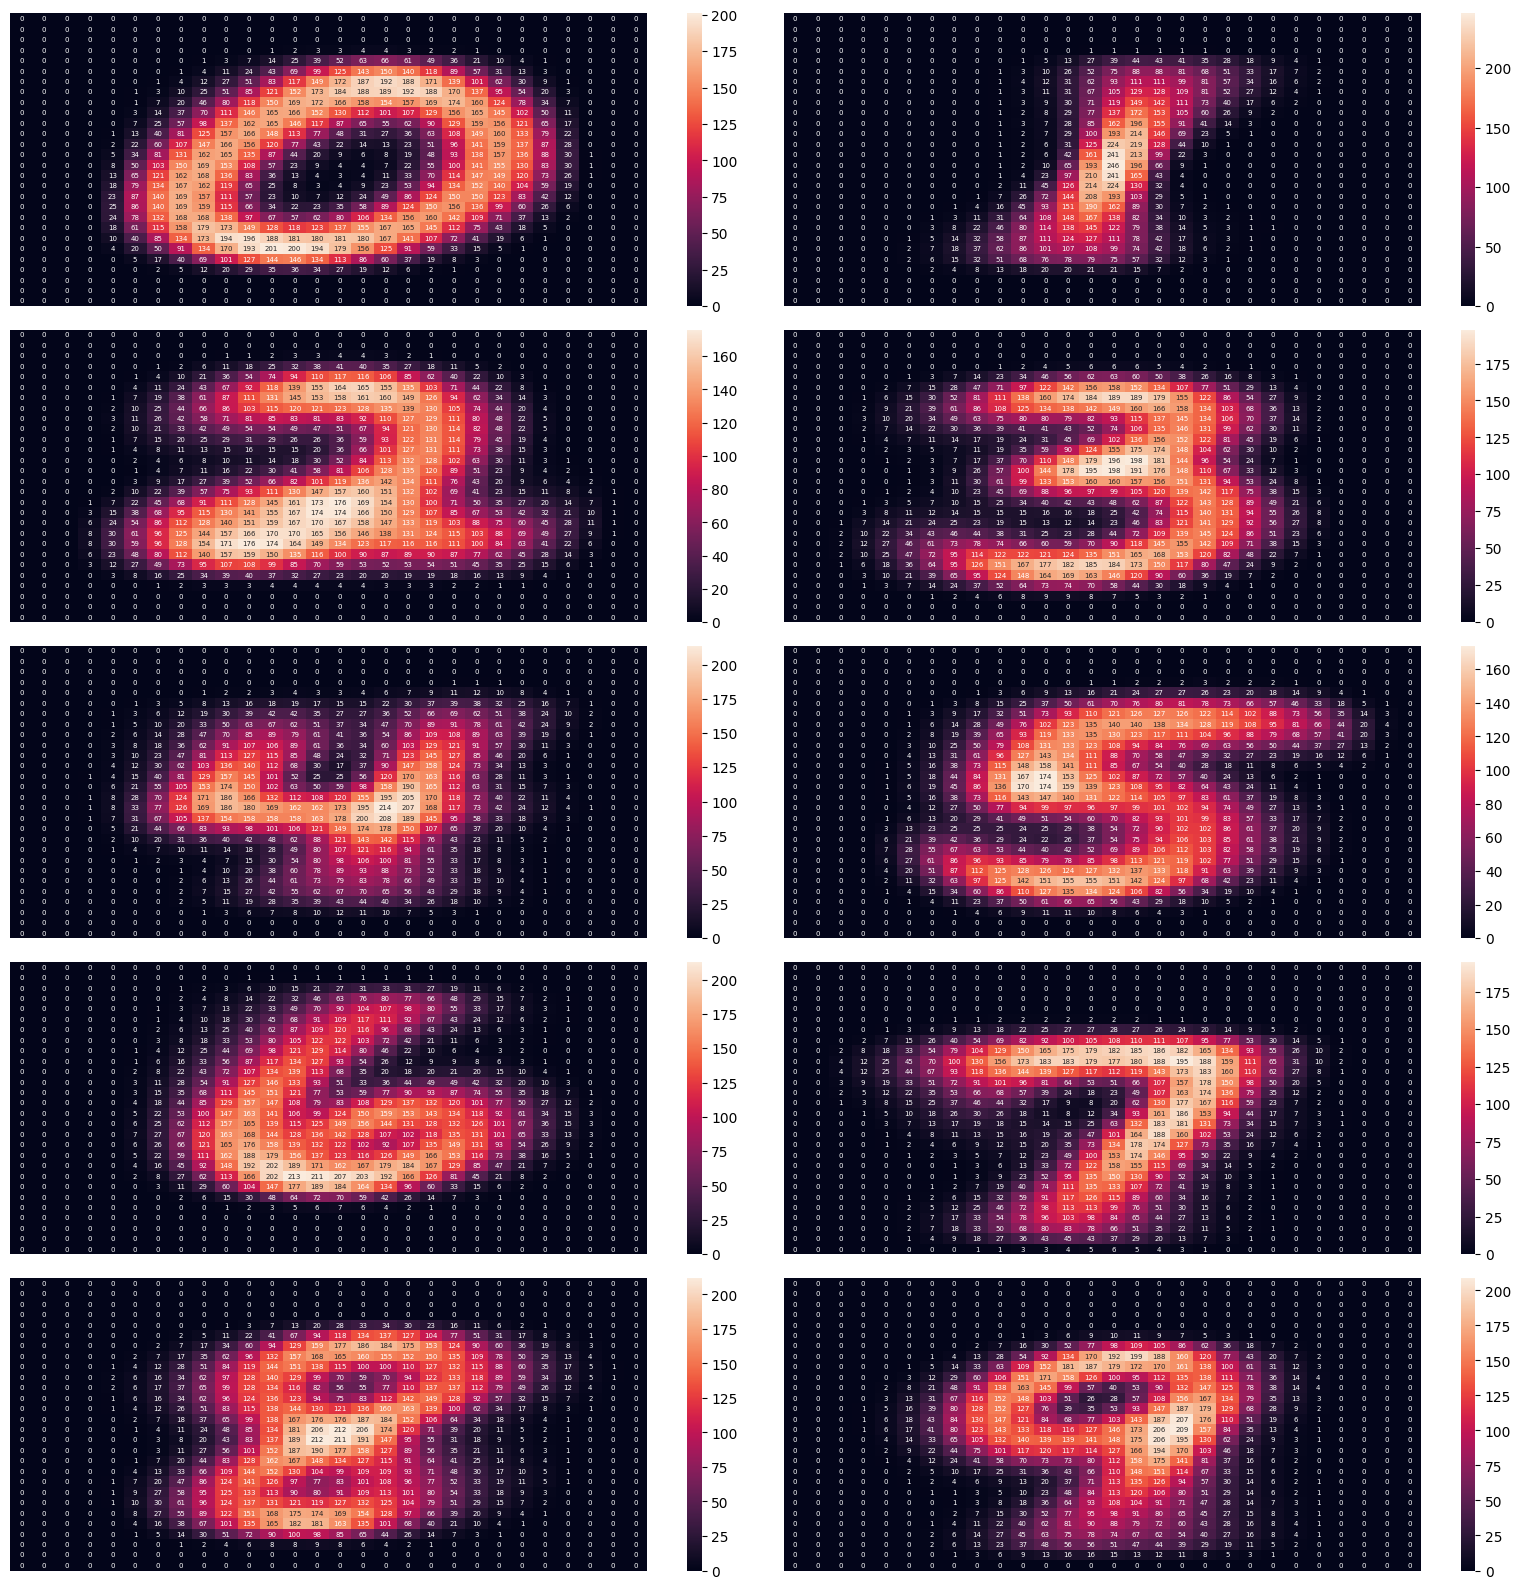

In [60]:
test = images.groupby('label').mean()
mean_img_classes = []
for i in range(len(test)):
    mean_img_classes.append(to_image(test.iloc[i]))


fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
axes = axes.flatten()
for i, matrix in enumerate(mean_img_classes):
    sns.heatmap(matrix, ax=axes[i], annot=True, fmt="d",annot_kws={"size": 5})
    # axes[i].set_title(titles[i], fontsize=16, weight='bold', pad=15) # Заголовок для каждого графика
    axes[i].axis('off')
plt.tight_layout()


In [21]:
# # images['1x1'].mean()



# total_height = sum(img.height for img in mean_img_classes)
# max_width = max(img.width for img in mean_img_classes)

# horizontal_combo = Image.new("RGB", (max_width, total_height))

# y_offset = 0
# for img in mean_img_classes:
#     horizontal_combo.paste(img, (0, y_offset))
#     y_offset += img.height

# plt.imshow(horizontal_combo)

In [22]:
# Image.fromarray((sum/len(X)).astype('uint8'), 'L').resize((256,256))

In [23]:
# test = images.dropna()
# print(images.shape, test.shape)
# test = images.drop_duplicates()
# print(X.shape)
# test = X.drop_duplicates()
duplicates = images.duplicated()
print('Дубликаты изображений с одинаковыми метками: ', duplicates.sum())
duplicates_diff = X.duplicated()
print('Дубликаты изображений с разными метками: ', duplicates_diff.sum())
print('Диапазон значений: ', X.min().min(), X.max().max())


Дубликаты изображений с одинаковыми метками:  0
Дубликаты изображений с разными метками:  0
Диапазон значений:  0 255


In [70]:

class NeuralNetwork(nn.Module):
    def __init__(self, p_val):
        super().__init__()
        self.p_val = p_val
        self.l1 = nn.Linear(28*28, 16)
        self.l2 = nn.Linear(16, 10)

    def forward(self, x):
        x = nn.functional.dropout(nn.functional.relu(self.l1(x)), self.p_val)
        # x = nn.functional.relu(self.l1(x))
        x = self.l2(x)
        return x


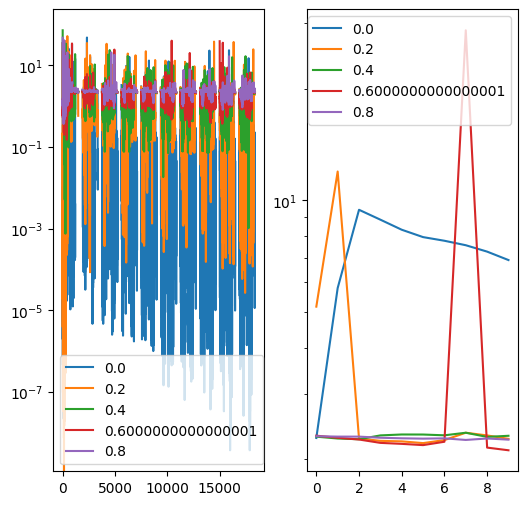

In [79]:
BATCH_SIZE = 32
EPOCHS = 10
test_label = []
models_with_different_p_balanced = []
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 6))
for p_val in range(0, 10, 2):
    model = NeuralNetwork(p_val * 0.1)
    opt = torch.optim.SGD(model.parameters(), lr=3e-4)
    loss_func = nn.CrossEntropyLoss()
    losses = []
    
    test_loss = []
    for j in range(EPOCHS):
        test_label = []
        labels = []
        for i in range(0, len(X), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_resampled_un[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            labels += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_resampled_un[i:i+BATCH_SIZE]), dtype=torch.long))
            loss.backward()
            opt.step()
            model.zero_grad()
            losses.append(loss.item())
        save_loss_test = []
        for i in range(0, len(X_test), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            test_label += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_test[i:i+BATCH_SIZE]), dtype=torch.long))
            save_loss_test.append(loss.item())
        test_loss.append(torch.tensor(save_loss_test).mean())
    models_with_different_p_balanced.append(model)

            
    axes[0].plot(losses, label=f'{p_val * 0.1}')
    axes[1].plot(test_loss, label=f'{p_val * 0.1}')
    
axes[0].legend()
# axes[0].set_ylim(0, 4)
axes[1].legend()
axes[0].set_yscale('log')
axes[1].set_yscale('log')
# plt.yscale('log')
# # plt.loglog()
# plt.ylim(0, 3)
plt.show()


In [85]:

for i, model_p in enumerate(models_with_different_p_balanced):
    metrics_test_labels = []
    for i in range(0, len(X_test), BATCH_SIZE):
        outputs = model_p(torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
        # print(outputs)
        metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
    print(f'metrivs for p = {i * 0.1}', metrics_cals(y_test, metrics_test_labels))

    


metrivs for p = 998.4000000000001 {'accuracy': 0.258, 'precision_micro': 0.258, 'precision_macro': 0.46553064687531354, 'recall_micro': 0.258, 'recall_macro': 0.252070642617509, 'f1_micro': 0.258, 'f1_macro': 0.2301448328976226}
metrivs for p = 998.4000000000001 {'accuracy': 0.2621, 'precision_micro': 0.2621, 'precision_macro': 0.47689221510879476, 'recall_micro': 0.2621, 'recall_macro': 0.2603513666712909, 'f1_micro': 0.2621, 'f1_macro': 0.22695648602102542}


/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


metrivs for p = 998.4000000000001 {'accuracy': 0.1626, 'precision_micro': 0.1626, 'precision_macro': 0.26079206609880506, 'recall_micro': 0.1626, 'recall_macro': 0.16351010598942145, 'f1_micro': 0.1626, 'f1_macro': 0.12115277945916106}
metrivs for p = 998.4000000000001 {'accuracy': 0.1846, 'precision_micro': 0.1846, 'precision_macro': 0.5533407962837174, 'recall_micro': 0.1846, 'recall_macro': 0.1815567803089212, 'f1_micro': 0.1846, 'f1_macro': 0.1483250669689478}


/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


metrivs for p = 998.4000000000001 {'accuracy': 0.1206, 'precision_micro': 0.1206, 'precision_macro': 0.35973012474896504, 'recall_micro': 0.1206, 'recall_macro': 0.11911589068372688, 'f1_micro': 0.1206, 'f1_macro': 0.05254289258207787}


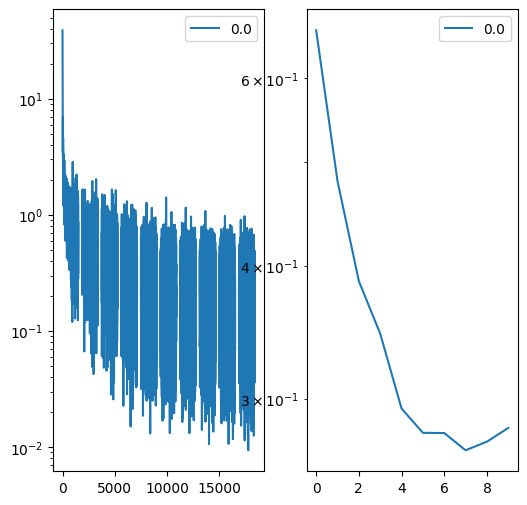

In [90]:
BATCH_SIZE = 32
EPOCHS = 10
test_label = []
models_with_different_p = []
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 6))
for p_val in range(0, 10, 10):
    model = NeuralNetwork(p_val * 0.1)
    opt = torch.optim.Adam(model.parameters(), lr=3e-4)
    loss_func = nn.CrossEntropyLoss()
    losses = []
    
    test_loss = []
    for j in range(EPOCHS):
        test_label = []
        labels = []
        for i in range(0, len(X), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_train[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            labels += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_train[i:i+BATCH_SIZE]), dtype=torch.long))
            loss.backward()
            opt.step()
            model.zero_grad()
            losses.append(loss.item())
        save_loss_test = []
        for i in range(0, len(X_test), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            test_label += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_test[i:i+BATCH_SIZE]), dtype=torch.long))
            save_loss_test.append(loss.item())
        test_loss.append(torch.tensor(save_loss_test).mean())
    models_with_different_p.append(model)

            
    axes[0].plot(losses, label=f'{p_val * 0.1}')
    axes[1].plot(test_loss, label=f'{p_val * 0.1}')
    
axes[0].legend()
# axes[0].set_ylim(0, 4)
axes[1].legend()
axes[0].set_yscale('log')
axes[1].set_yscale('log')
# plt.yscale('log')
# # plt.loglog()
# plt.ylim(0, 3)
plt.show()


In [ ]:

for i, model_p in enumerate(models_with_different_p):
    metrics_test_labels = []
    for i in range(0, len(X_test), BATCH_SIZE):
        outputs = model_p(torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
        # print(outputs)
        metrics_test_labels += torch.argmax(outputs.detach(), dim=1)
    print(f'metrivs for p = {i * 0.1}', metrics_cals(y_test, metrics_test_labels))



metrivs for p = 998.4000000000001 {'accuracy': 0.9538, 'precision_micro': 0.9538, 'precision_macro': 0.9531457144501194, 'recall_micro': 0.9538, 'recall_macro': 0.953537930781342, 'f1_micro': 0.9538, 'f1_macro': 0.9531441250789745}
metrivs for p = 998.4000000000001 {'accuracy': 0.9129, 'precision_micro': 0.9129, 'precision_macro': 0.9133204280842733, 'recall_micro': 0.9129, 'recall_macro': 0.9120396016202464, 'f1_micro': 0.9129, 'f1_macro': 0.9121850985034093}
metrivs for p = 998.4000000000001 {'accuracy': 0.8489, 'precision_micro': 0.8489, 'precision_macro': 0.8556823323655008, 'recall_micro': 0.8489, 'recall_macro': 0.84748472270221, 'f1_micro': 0.8489, 'f1_macro': 0.8484571691646249}
metrivs for p = 998.4000000000001 {'accuracy': 0.6145, 'precision_micro': 0.6145, 'precision_macro': 0.6967134759116164, 'recall_micro': 0.6145, 'recall_macro': 0.610464589074034, 'f1_micro': 0.6145, 'f1_macro': 0.6268166751976118}
metrivs for p = 998.4000000000001 {'accuracy': 0.2652, 'precision_micro'

In [84]:
def metrics_cals(y, labels):
    accuracy = accuracy_score(y, labels)
    precision_micro = precision_score(y, labels, average='micro')
    precision_macro = precision_score(y, labels, average='macro')
    recall_micro = recall_score(y, labels, average='micro')
    recall_macro = recall_score(y, labels, average='macro')
    f1_macro = f1_score(y, labels, average='macro')
    f1_micro = f1_score(y, labels, average='micro')

    return {'accuracy': accuracy,
    'precision_micro': precision_micro,
    'precision_macro': precision_macro,
    'recall_micro': recall_micro,
    'recall_macro': recall_macro,
    'f1_micro': f1_micro,
    'f1_macro': f1_macro,}


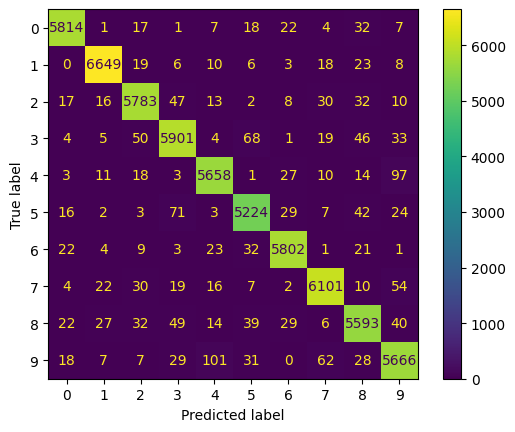

In [137]:


cm = confusion_matrix(y, labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


<Axes: >

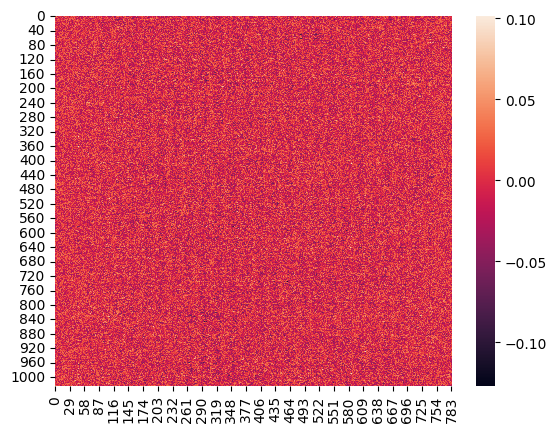

In [138]:
sns.heatmap(model.l1.weight.detach())
# plt.imshow(model.l1.weight.detach(), cmap='magma', aspect='auto')

In [62]:
def vector_to_image_dim(vector_data, size_m):
    # Извлекаем данные для конкретного нейрона (размерность [FLATTEN_DIM])
    neuron_vector = vector_data.mean(dim=0).detach().cpu().numpy()

    # Сначала возвращаем пространственную форму последней свертки: [C, H, W]
    spatial_map = neuron_vector.reshape(1, size_m, size_m)

    # Усредняем по каналам (или берем максимум), чтобы получить 2D-карту активации [H, W]
    heatmap2d = np.mean(spatial_map, axis=0)

    # Нормализуем в диапазон [0, 1] для корректного отображения
    heatmap2d = (heatmap2d - heatmap2d.min()) / (
        heatmap2d.max() - heatmap2d.min() + 1e-8
    )

    # Апсемплим (интерполируем) до размеров исходного изображения [IMG_H, IMG_W]
    # heatmap_resized = heatmap2d, (IMG_W, IMG_H))
    return heatmap2d


<Axes: >

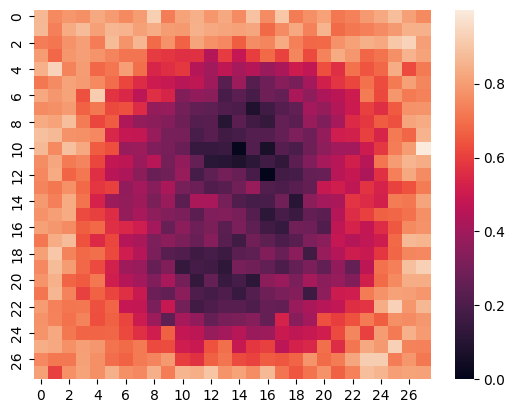

In [140]:
sns.heatmap(vector_to_image_dim(model.l1.weight, 28))

In [141]:
model.l2.weight.shape

torch.Size([10, 1024])

In [142]:
X[0:1]

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


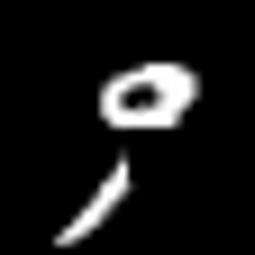

In [69]:
test_sdajasd = np.array(to_image(X[33:34]))
test_sdajasd[14:20, 14:20] = 0
Image.fromarray(test_sdajasd).resize((255,255))
# to_image(X[33:34]).resize((256,256))

In [64]:
test_img = torch.Tensor(np.array(X[4:5], dtype=np.float32))
# model(test_img)
# vector_to_image_dim(model.l1(test_img), 28)
# model.l1.weight.detach().T) @ model.l2.weight.detach().T
sns.heatmap(nn.functional.relu(test_img @ model.l1.weight.detach().T) @ model.l2.weight.detach().T)#vector_to_image_dim(model.l1.weight, 28)))

NameError: name 'model' is not defined

In [ ]:
# sns.heatmap(vector_to_image_dim(model.l2.weight, 2))

ValueError: cannot reshape array of size 1024 into shape (1,2,2)

In [336]:
img_test = np.array(to_image(X.iloc[33]))
# img_test[0:28, 0:14] = 0
Image.fromarray(img_test)

In [337]:
outputs = model(torch.Tensor(np.array(img_test, dtype=np.float32)).reshape(784))    
nn.functional.softmax(outputs)[4]

/var/folders/n7/bw699rhs7ybdyc399m3wwz6c0000gn/T/ipykernel_91923/1174961565.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  nn.functional.softmax(outputs)[4]


tensor(2.7930e-08, grad_fn=<SelectBackward0>)

In [341]:
def occlusion(model, kernel, image, right_class):
    img_tets = torch.zeros((28, 28))

    for i in range(0, 28):
        for j in range(0, 28):
            image_copy = image.copy()
            image_copy[i:i+kernel, j:j+kernel] = 0
            with torch.no_grad():
                outputs = model(torch.Tensor(np.array(image_copy, dtype=np.float32)).reshape(784))    
            img_tets[i:i+kernel, j:j+kernel] +=  1 - nn.functional.softmax(outputs, dim=0)[right_class]
    # sns.heatmap(img_tets.detach())
    return img_tets
        

<Axes: >

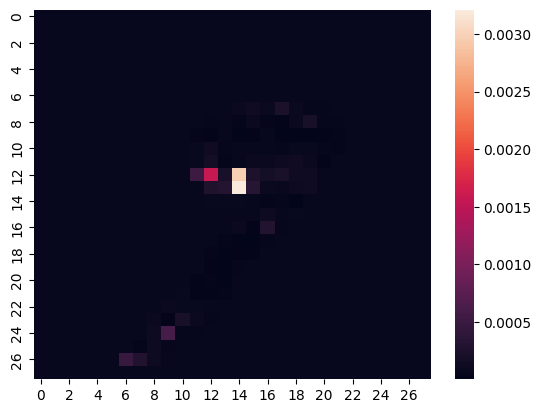

In [342]:
sns.heatmap(occlusion(model, 1, np.array(to_image(X.iloc[33])), 9))

<Axes: >

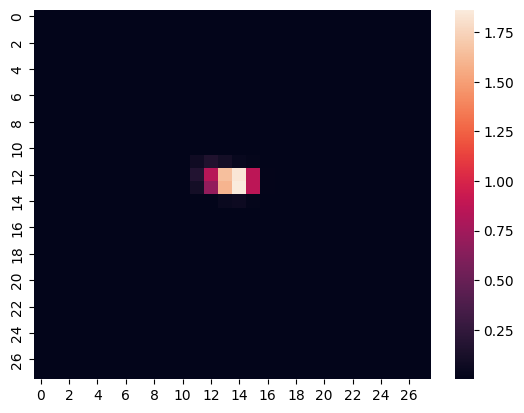

In [343]:
sns.heatmap(occlusion(model, 2, np.array(to_image(X.iloc[33])), 9))

<Axes: >

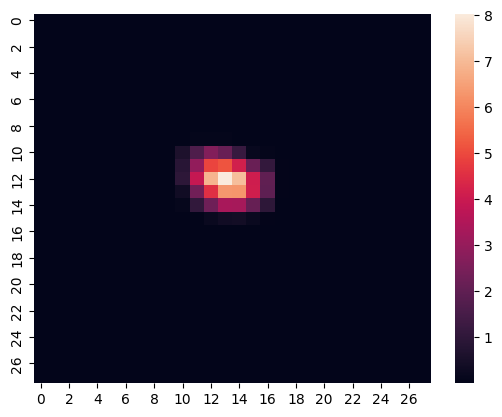

In [344]:

sns.heatmap(occlusion(model, 3, np.array(to_image(X.iloc[33])), 9))


In [297]:
# sns.heatmap(kek.detach()) #Image.fromarray(kek.detach().numpy(), mode='L')
# test_kek.resize((256, 256))
# sns.heatmap(test_kek)


In [345]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# def get_occlusion_heatmap(model, input_tensor, target_class, kernel_size=3, stride=1, occlude_value=0):
#     """
#     input_tensor: тензор формы (1, C, H, W)
#     kernel_size: 1, 2 или 3
#     occlude_value: значение, которым заменяем пиксели (например, 0 для черного)
#     """
#     model.eval()
    
#     # # 1. Получаем базовую вероятность без окклюзии
#     # with torch.no_grad():
#     #     output = torch.softmax(model(input_tensor.reshape((28*28))), dim=0)
#     #     p_orig = output[target_class].item()
        
#     height, width = input_tensor.shape
#     # channels = 1
#     # # Инициализируем карту чувствительности
#     heatmap = np.zeros((height, width))
#     # # Матрица для подсчета, сколько раз пиксель перекрывался (для усреднения при stride > 1)
#     counts = np.zeros((height, width))
    
#     # 3. Скользящее окно
#     for y in range(0, height - kernel_size + 1, stride):
#         for x in range(0, width - kernel_size + 1, stride):
            
#             # Копируем исходный тензор, чтобы не испортить его
#             input_occluded = input_tensor.clone()
            
#             # 4. Маскируем область ядра [kernel_size x kernel_size]
#             input_occluded[y:y+kernel_size, x:x+kernel_size] = occlude_value
            
#             # 5. Инференс
#             with torch.no_grad():
#                 output_occluded = torch.softmax(model(input_occluded.reshape((28*28))), dim=0)
#                 p_new = output_occluded[target_class].item()
            
#             # 6. Считаем падение уверенности
#             score = 1 - p_new
            
#             # Записываем результат во все пиксели текущего окна
#             heatmap[y:y+kernel_size, x:x+kernel_size] += score
#             counts[y:y+kernel_size, x:x+kernel_size] += 1
            
#     # Усредняем значения по пикселям
#     # heatmap = np.divide(heatmap, counts, out=np.zeros_like(heatmap), where=counts!=0)
    
#     # Нормализуем от 0 до 1 для красивой визуализации
#     # heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
#     sns.heatmap(heatmap)
#     return heatmap


In [347]:
# Image.fromarray(get_occlusion_heatmap(model, torch.tensor(X.iloc[30], dtype=torch.float32).reshape((28,28)), 3, 1), mode='L')